In [16]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp
from eigenshuffle import eigenshuffle_eig
import numpy as np
from scipy.optimize import linear_sum_assignment
import scienceplots

def track_eigenvalues(all_evals, weight_real=1.0, weight_imag=10.0):
    T, N = all_evals.shape
    tracked_eigvals = np.zeros((T, N), dtype=np.complex128)
    
    # --- Paso t=0 ---
    idx_0 = np.argsort(all_evals[0].imag)
    tracked_eigvals[0] = all_evals[0][idx_0]
    
    # --- Pasos t > 0 ---
    for t in range(1, T):
        prev_eigs = tracked_eigvals[t-1]
        curr_eigs = all_evals[t]
        
        # 1. ¡CORRECCIÓN AQUÍ! prev_eigs son las filas (eje 0), curr_eigs las columnas (eje 1)
        diff = prev_eigs[:, None] - curr_eigs[None, :]
        
        # Distancias al cuadrado
        dist_real = np.abs(diff.real)**2
        dist_imag = np.abs(diff.imag)**2
        
        # 2. Matriz de Coste Mixta
        cost_matrix = (weight_real * dist_real) + (weight_imag * dist_imag)
        
        # 3. Asignación (Algoritmo Húngaro)
        _, col_ind = linear_sum_assignment(cost_matrix)
        
        # 4. Guardar resultado (Ahora sí aplicará el orden correctamente)
        tracked_eigvals[t] = curr_eigs[col_ind]
        
    return tracked_eigvals

@njit(fastmath=True)
def hopfield(STEPS, W, X_0, DT):
    DIM = X_0.shape[0]
    X_time_series = np.zeros((STEPS, DIM))
    X_time_series[0] = X_0
    for t in range(1, STEPS):
        if t % 10 == 0:
            print(f"Paso {t}/{STEPS}")
        for i in range(DIM):
            sum = 0
            for j in range(DIM):
                sum += W[i, j] * X_time_series[t-1, j]

            X_time_series[t, i] = np.tanh(sum)
    
    return X_time_series

def ODE_system(t, y, dim, alpha):
    X = y[:dim]
    W = y[dim:].reshape((dim, dim))

    dim = np.shape(X)[0]
    dWdt = alpha * (np.eye(dim) - np.outer(X, X))
    dXdt = W @ X

    return np.concatenate([dXdt, dWdt.flatten()])

def track_eigen_inertia(all_evals):
    """
    all_evals: array de dimensiones (T, N) con los autovalores precalculados.
    """
    T, N = all_evals.shape
    tracked_evals = np.zeros((T, N), dtype=np.complex128)
    
    if T == 0:
        return tracked_evals
        
    # --- Paso t=0 ---
    # Usamos la parte imaginaria como estado inicial base (como indicaste que iba mejor)
    idx_0 = np.argsort(all_evals[0].imag)
    tracked_evals[0] = all_evals[0][idx_0]
    
    if T == 1:
        return tracked_evals

    # --- Paso t=1 (Aún no hay inercia, usamos distancia normal) ---
    curr_evals = all_evals[1]
    prev_evals = tracked_evals[0]
    
    # prev_evals en filas (eje 0), curr_evals en columnas (eje 1)
    cost_matrix = np.abs(prev_evals[:, None] - curr_evals[None, :])
    _, col_ind = linear_sum_assignment(cost_matrix)
    tracked_evals[1] = curr_evals[col_ind]

    # --- Pasos t >= 2 (Uso de inercia / predicción) ---
    for t in range(2, T):
        curr_evals = all_evals[t]
        
        # 1. Calculamos la "velocidad" (cuánto se movieron en el último paso)
        velocidad = tracked_evals[t-1] - tracked_evals[t-2]
        
        # 2. Predecimos dónde deberían estar ahora
        prediccion = tracked_evals[t-1] + velocidad
        
        # 3. Emparejamos los actuales con la PREDICCIÓN, no con la posición anterior.
        # Las predicciones son nuestras filas, los valores actuales las columnas.
        cost_matrix = np.abs(prediccion[:, None] - curr_evals[None, :])
        
        # 4. Asignación (Algoritmo Húngaro)
        _, col_ind = linear_sum_assignment(cost_matrix)
        
        # 5. Guardamos el resultado ordenado
        tracked_evals[t] = curr_evals[col_ind]
        
    return tracked_evals

## Figura de estabilidad de autovalores

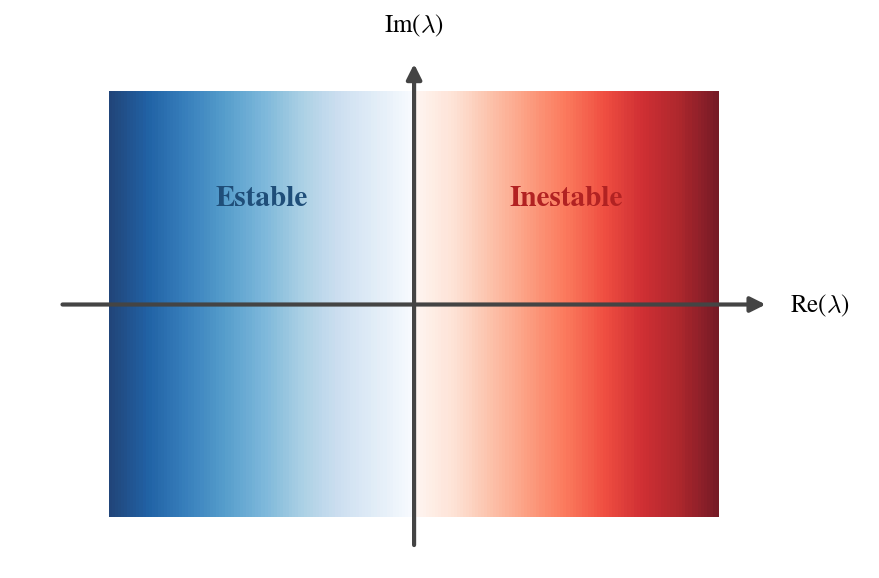

In [ ]:

# 1. Inicializar la figura con alta resolución para impresión (DPI alto)
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

# 2. Crear el degradado de fondo
# Lado izquierdo (Estable - Azul) que se desvanece al acercarse a 0
grid_left = np.tile(np.linspace(1, 0, 100), (100, 1))
ax.imshow(grid_left, cmap='Blues', extent=[-3, 0, -2, 2], alpha=0.9, aspect='auto')

# Lado derecho (Inestable - Rojo) que aparece a partir de 0
grid_right = np.tile(np.linspace(0, 1, 100), (100, 1))
ax.imshow(grid_right, cmap='Reds', extent=[0, 3, -2, 2], alpha=0.9, aspect='auto')

# 3. Dibujar los ejes personalizados con flechas en las puntas
# Eje Horizontal (Real)
ax.annotate('', xy=(3.5, 0), xytext=(-3.5, 0),
            arrowprops=dict(arrowstyle="-|>", color="#444444", lw=2, mutation_scale=15))
# Eje Vertical (Imaginario)
ax.annotate('', xy=(0, 2.3), xytext=(0, -2.3),
            arrowprops=dict(arrowstyle="-|>", color="#444444", lw=2, mutation_scale=15))

# 4. Añadir las etiquetas matemáticas de los ejes
ax.text(3.7, 0, r'Re($\lambda$)', va='center', ha='left', fontsize=12)
ax.text(0, 2.5, r'Im($\lambda$)', va='bottom', ha='center', fontsize=12)

# 5. Añadir los textos "Stable" y "Unstable" con sus respectivos colores
ax.text(-1.5, 1, 'Estable', color='#1f4e79', fontsize=14, ha='center', va='center', weight='bold')
ax.text(1.5, 1, 'Inestable', color='#b22222', fontsize=14, ha='center', va='center', weight='bold')

# 6. Limpieza estética: Ocultar los bordes y marcas por defecto de matplotlib
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Configurar límites estrictos de la vista para que no se corte nada
ax.set_xlim(-4, 4.5)
ax.set_ylim(-2.5, 2.8)

plt.tight_layout()
plt.show()

## Evolución de autovalores

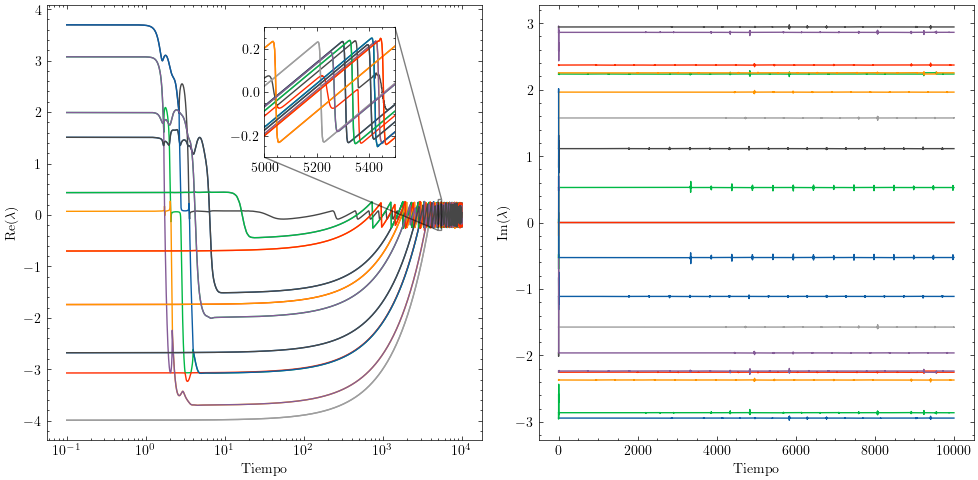

In [3]:
dim = 20
time = 10000
t_eval = np.logspace(-1, 4, 150000)
alpha = 0.001

rng_X = np.random.default_rng(42)
rng_W = np.random.default_rng(69)

X_0 = rng_X.normal(loc=0, scale=1/np.sqrt(dim), size=dim)
W_0 = rng_W.normal(loc=0, scale=1, size=(dim, dim))

y_0 = np.concatenate([X_0, W_0.flatten()])
solution = solve_ivp(ODE_system, [0, time], y0=y_0, args=[dim, alpha], t_eval=t_eval, method='DOP853')

X = solution.y[:dim, :].transpose()
W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)

# eigenvalues = track_eigenvalues(W)
eigenvalues = np.linalg.eigvals(W)
eigenvalues = track_eigenvalues(eigenvalues, weight_real=1, weight_imag=10)

plt.style.use(['science'])

fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].semilogx(t_eval, eigenvalues.real, lw=1, rasterized=True)
ax[1].plot(t_eval, eigenvalues.imag, lw=1, rasterized=True)
ax[0].set_box_aspect(1)
ax[1].set_box_aspect(1)

# Inset axes
axins = ax[0].inset_axes([0.5, 0.65, 0.3, 0.3], xlim=[5000, 5500], ylim=[-0.3, 0.3])
axins.plot(t_eval, eigenvalues.real, lw=1)
ax[0].indicate_inset_zoom(axins, edgecolor='black')

# Títulos y texto
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel(r"Re$(\lambda)$")

ax[1].set_xlabel("Tiempo")
ax[1].set_ylabel(r"Im$(\lambda)$")

plt.tight_layout()

plt.savefig("Figures/Evolucion coloreada.pdf")
plt.show()

# W_norm = np.linalg.norm(W, axis=(1, 2))
# X_norm = np.linalg.norm(X, axis=1)

# y = X_norm**2
# y_dotdot = np.gradient(np.gradient(y, t_eval), t_eval)

# plt.plot(y_dotdot, y, 'b.', ms=1)
# plt.show()

# V = 0.5 * W_norm**2 + alpha * (0.5 * X_norm**2 - np.log(X_norm))
# dVdt = (np.trace(W, axis1=1, axis2=2) - np.einsum('ti, tij, tj -> t', X, W, X)/X_norm**2)
# V_dot = np.gradient(V, t_eval)

# plt.plot(t_eval, (V - V.mean())/(V.max()-V.min()), label='Lyapunov function')
# plt.plot(t_eval, (V_dot - V_dot.mean())/(V_dot.max()-V_dot.min()), label=r"$\frac{dV}{dt}$ numérica", alpha=0.8)
# plt.plot(t_eval, (dVdt - dVdt.mean())/(dVdt.max()-dVdt.min()), label=r"$\frac{dV}{dt}$ analítica", alpha=0.8)
# plt.legend()
# plt.show()

# print("X: ", X.shape)
# print("W: ", W.shape)
# WX = np.einsum('tij, tj -> ti', W, X)
# WX_norm = np.linalg.norm(WX, axis=1)
# X_norm = np.linalg.norm(X, axis=1)

# W_spectral_norm = np.linalg.norm(W, ord=2, axis=(1, 2))

# plt.plot(WX_norm, label=r"$|WX|$")
# plt.plot(W_norm * X_norm/2, label=r"$|W||X|$")
# # plt.plot(W_spectral_norm * X_norm, label=r"$\sigma_{max}(W)|X|$")
# plt.legend()
# plt.show()



## Circular Law

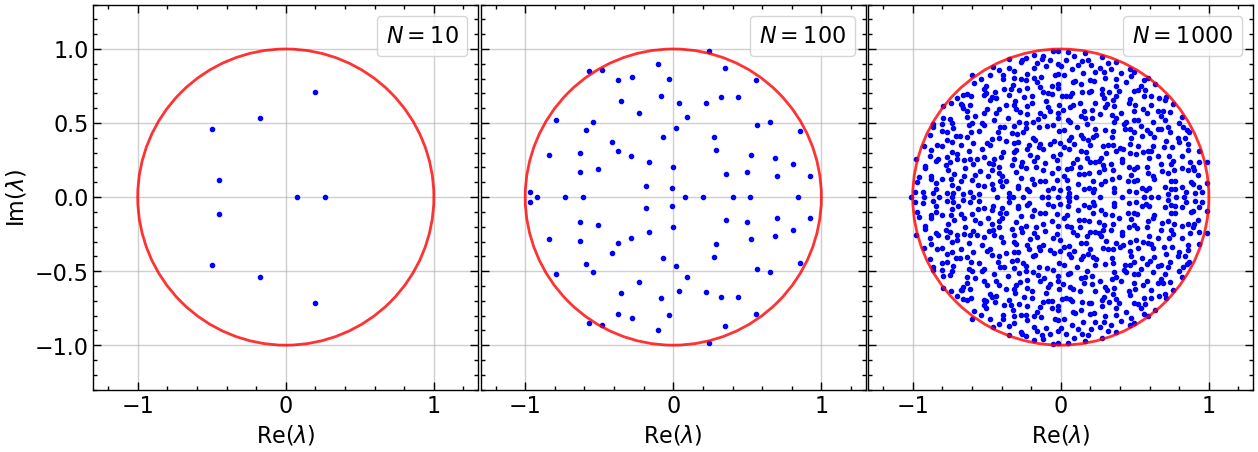

In [33]:
from matplotlib.patches import Circle
dims = [10, 100, 1000]

matrices = [np.random.standard_normal((dim, dim)) for dim in dims]

autovalores = [np.linalg.eigvals(matrix) for matrix in matrices]

plt.style.use(['science', 'notebook'])

fig, ax = plt.subplots(ncols=3, figsize=(15, 5), sharey=True, gridspec_kw={'wspace': 0})

for i in range(3):
    autovalores[i] = autovalores[i]/np.sqrt(dims[i])
    ax[i].plot(autovalores[i].real, autovalores[i].imag, 'b.', label=fr"$N = {dims[i]}$")
    ax[i].set_aspect('equal')
    ax[i].set_xlabel(r"Re$(\lambda)$")
    circle = Circle([0, 0], 1.0, edgecolor='red', fill=False, linewidth=2, zorder=5, alpha=0.8)
    ax[i].add_patch(circle)
    ax[i].grid(True, alpha=0.6)
    ax[i].set_xlim(-1.3, 1.3)
    ax[i].set_ylim(-1.3, 1.3)
    ax[i].legend(frameon=True, markerscale=0, handletextpad=0, handlelength=0)
    if i > 0:
        ax[i].tick_params(labelleft=False)
ax[0].set_ylabel(r"Im$(\lambda)$")

plt.savefig("Figures/circular law.pdf")
plt.show()

## Excitación de modos

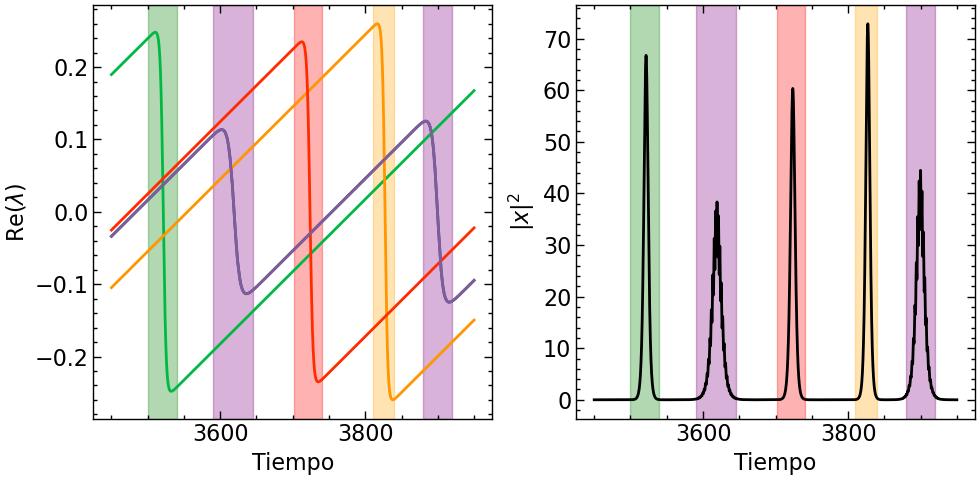

[-0.09480991-1.58332644j  0.16740932+0.j         -0.14963851+0.j
 -0.02225634+0.j         -0.09480991+1.58332644j]


In [40]:
dim = 5
rng_W = np.random.default_rng(42)
rng_X = np.random.default_rng(42)
time = 4000
alpha = 0.001
t_eval = np.linspace(3450, 3950, 10000)

W_0 = rng_W.standard_normal((dim, dim))
X_0= rng_X.standard_normal(dim)

y_0 = np.concatenate([X_0, W_0.flatten()])
solution = solve_ivp(ODE_system, [0, time], y0=y_0, args=[dim, alpha], t_eval=t_eval, method='DOP853')

X = solution.y[:dim, :].transpose()
W = solution.y[dim:, :].reshape((dim, dim, -1)).transpose(2, 0, 1)

X_norm = np.linalg.norm(X, axis=1)**2

eigenvalues = np.linalg.eigvals(W)

eigenvalues = track_eigen_inertia(eigenvalues)

plt.style.use(['science', 'notebook'])
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))

ax[0].plot(t_eval, eigenvalues.real)
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel(r"Re$(\lambda)$")
ax[0].axvspan(xmin=3500, xmax=3540, color='green', alpha=0.3)
ax[0].axvspan(xmin=3590, xmax=3645, color='purple', alpha=0.3)
ax[0].axvspan(xmin=3702, xmax=3740, color='red', alpha=0.3)
ax[0].axvspan(xmin=3810, xmax=3840, color='orange', alpha=0.3)
ax[0].axvspan(xmin=3880, xmax=3920, color='purple', alpha=0.3)

ax[1].plot(t_eval, X_norm, c='k')
ax[1].set_xlabel("Tiempo")
ax[1].set_ylabel(r"$|x|^2$")
ax[1].axvspan(xmin=3500, xmax=3540, color='green', alpha=0.3)
ax[1].axvspan(xmin=3590, xmax=3645, color='purple', alpha=0.3)
ax[1].axvspan(xmin=3702, xmax=3740, color='red', alpha=0.3)
ax[1].axvspan(xmin=3810, xmax=3840, color='orange', alpha=0.3)
ax[1].axvspan(xmin=3880, xmax=3920, color='purple', alpha=0.3)

plt.tight_layout()
plt.savefig("Figures/Picos.pdf")
plt.show()

print(eigenvalues[-1])
